<a href="https://colab.research.google.com/github/Vaishnavi-Junghare/ML/blob/main/ml_pract9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ml_lab-9
vaishnavi junghare(cs23024)

aim:to implement the k-mean clustering algorithm and anallyze the clustering result using appropriate evalution technique

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path= "/content/drive/MyDrive/ml_dataset/Mall_Customers.csv"
df=pd.read_csv(path)
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [ ]:
df.shape

(200, 5)

In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.isnull().any().any()

np.False_

In [ ]:
df[df.isnull().any(axis = 1)]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
X=df.iloc[:,[3,4]].values
print(X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

In [ ]:
scaler =StandardScaler()
X_scaled = scaler.fit_transform(X)

[399.99999999999994, 273.66888662642003, 157.70400815035939, 109.22822707921345, 65.56840815571681, 60.132874871934206, 49.668244837367965, 37.31912287833882, 32.495081199100916, 30.05932269404222]


Text(0.5, 1.0, 'Elbow Method')

<Figure size 640x480 with 0 Axes>

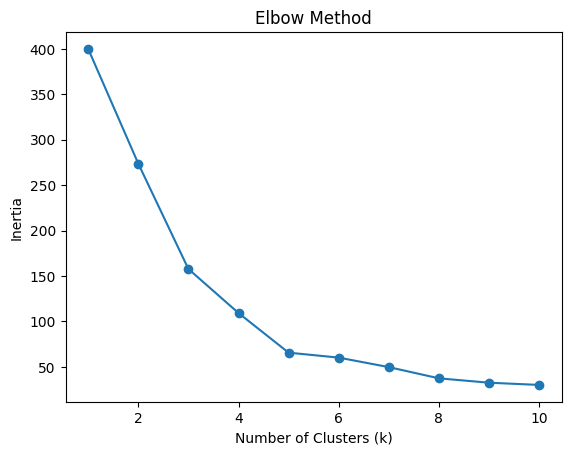

In [ ]:
inertia_values = []

for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia_values.append(kmeans.inertia_)

print(inertia_values)

plt.figure()
plt.figure()
plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')


In [ ]:

kmeans = KMeans(n_clusters=5, random_state=42)
cluster=kmeans.fit_predict(X_scaled)
df['cluster']=cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


In [ ]:
print("inertia:",kmeans.inertia_)
sil_scpre=silhouette_score(X_scaled,cluster)
print("silhouette score:",sil_scpre)


inertia: 65.56840815571681
silhouette score: 0.5546571631111091


[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


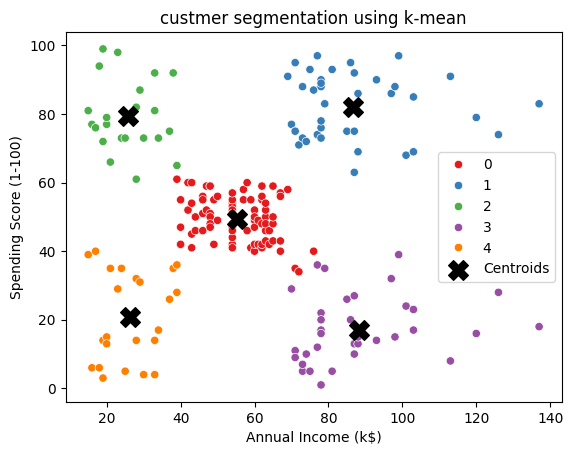

In [ ]:
plt.figure
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='cluster',data=df,palette='Set1')
centrods=scaler.inverse_transform(kmeans.cluster_centers_)
print(centrods)
plt.scatter(
    centrods[:,0],
    centrods[:,1],
    marker='X',
    s=200,
    c='black',
    label='Centroids'
)
plt.title("custmer segmentation using k-mean")
plt.legend()
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster=kmeans.fit_predict(X_scaled)
df['cluster']=cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        2  
1        2  
2        2  
3        2  
4        2  


In [ ]:
print("inertia:",kmeans.inertia_)
sil_scpre=silhouette_score(X_scaled,cluster)
print("silhouette score:",sil_scpre)


inertia: 157.70400815035939
silhouette score: 0.46658474419000145


[[87.         18.63157895]
 [86.53846154 82.12820513]
 [44.15447154 49.82926829]]


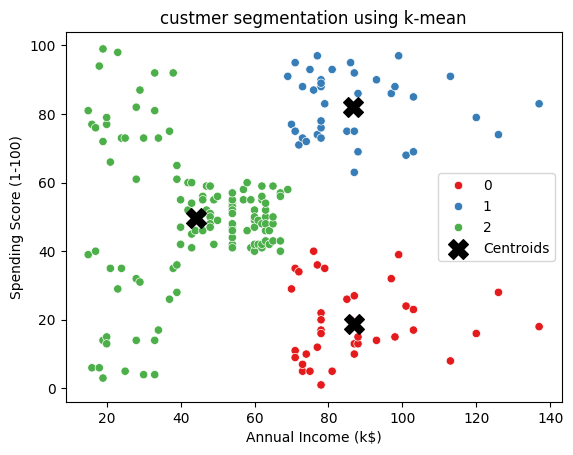

In [ ]:
plt.figure
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='cluster',data=df,palette='Set1')
centrods=scaler.inverse_transform(kmeans.cluster_centers_)
print(centrods)
plt.scatter(
    centrods[:,0],
    centrods[:,1],
    marker='X',
    s=200,
    c='black',
    label='Centroids'
)
plt.title("custmer segmentation using k-mean")
plt.legend()
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
cluster=kmeans.fit_predict(X_scaled)
df['cluster']=cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        0  
1        2  
2        0  
3        2  
4        0  


In [ ]:
print("inertia:",kmeans.inertia_)
sil_scpre=silhouette_score(X_scaled,cluster)
print("silhouette score:",sil_scpre)



inertia: 109.22822707921345
silhouette score: 0.49434988482196784


[[48.16831683 43.3960396 ]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [87.         18.63157895]]


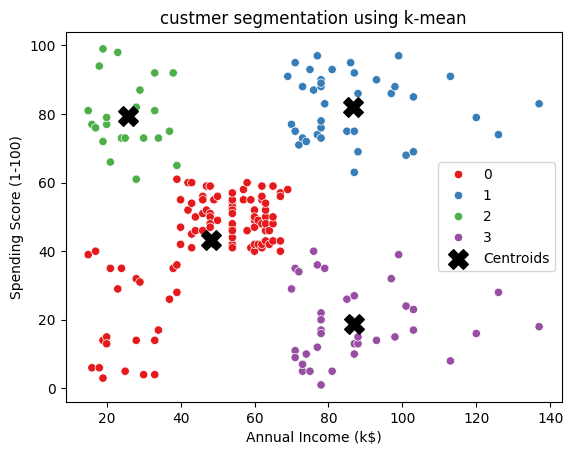

In [ ]:
plt.figure
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='cluster',data=df,palette='Set1')
centrods=scaler.inverse_transform(kmeans.cluster_centers_)
print(centrods)
plt.scatter(
    centrods[:,0],
    centrods[:,1],
    marker='X',
    s=200,
    c='black',
    label='Centroids'
)
plt.title("custmer segmentation using k-mean")
plt.legend()
plt.show()


In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
cluster=kmeans.fit_predict(X_scaled)
df['cluster']=cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        5  
1        2  
2        4  
3        2  
4        5  


In [ ]:
print("inertia:",kmeans.inertia_)
sil_scpre=silhouette_score(X_scaled,cluster)
print("silhouette score:",sil_scpre)

inertia: 60.132874871934206
silhouette score: 0.5138257534676561


[[56.05194805 49.85714286]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [24.58333333  9.58333333]
 [31.53333333 35.86666667]]


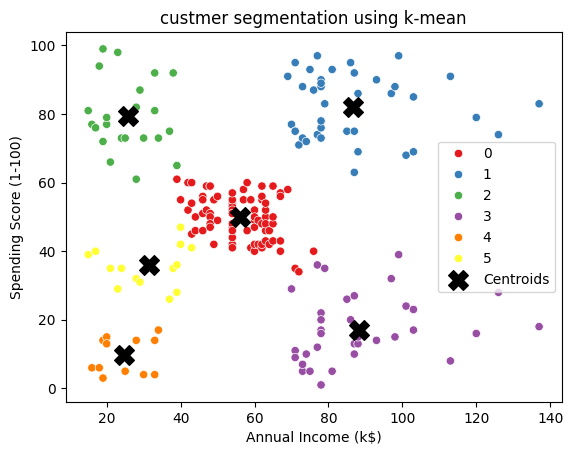

In [ ]:
plt.figure
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='cluster',data=df,palette='Set1')
centrods=scaler.inverse_transform(kmeans.cluster_centers_)
print(centrods)
plt.scatter(
    centrods[:,0],
    centrods[:,1],
    marker='X',
    s=200,
    c='black',
    label='Centroids'
)
plt.title("custmer segmentation using k-mean")
plt.legend()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=7, random_state=42)
cluster=kmeans.fit_predict(X_scaled)
df['cluster']=cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        5  
1        2  
2        4  
3        2  
4        5  


In [ ]:
print("inertia:",kmeans.inertia_)
sil_scpre=silhouette_score(X_scaled,cluster)
print("silhouette score:",sil_scpre)

inertia: 49.668244837367965
silhouette score: 0.50200146805547


[[ 56.05194805  49.85714286]
 [108.18181818  82.72727273]
 [ 25.72727273  79.36363636]
 [ 88.2         17.11428571]
 [ 24.58333333   9.58333333]
 [ 31.53333333  35.86666667]
 [ 78.03571429  81.89285714]]


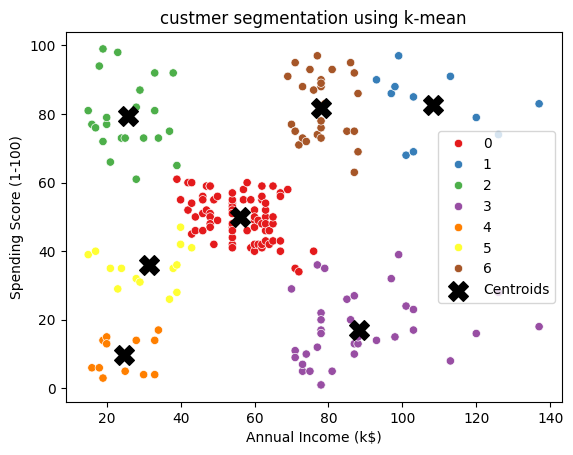

In [ ]:
plt.figure
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='cluster',data=df,palette='Set1')
centrods=scaler.inverse_transform(kmeans.cluster_centers_)
print(centrods)
plt.scatter(
    centrods[:,0],
    centrods[:,1],
    marker='X',
    s=200,
    c='black',
    label='Centroids'
)
plt.title("custmer segmentation using k-mean")
plt.legend()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=8, random_state=42)
cluster=kmeans.fit_predict(X_scaled)
df['cluster']=cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        4  
1        3  
2        4  
3        3  
4        4  


In [ ]:
print("inertia:",kmeans.inertia_)
sil_scpre=silhouette_score(X_scaled,cluster)
print("silhouette score:",sil_scpre)

inertia: 37.31912287833882
silhouette score: 0.4550112502601921


[[ 61.30188679  48.24528302]
 [108.18181818  82.72727273]
 [ 79.70833333  14.29166667]
 [ 24.95        81.        ]
 [ 25.14285714  19.52380952]
 [ 78.03571429  81.89285714]
 [ 43.96969697  51.12121212]
 [109.7         22.        ]]


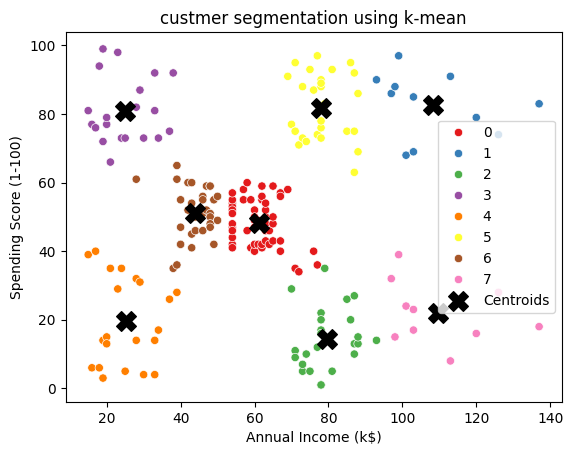

In [ ]:
plt.figure
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',hue='cluster',data=df,palette='Set1')
centrods=scaler.inverse_transform(kmeans.cluster_centers_)
print(centrods)
plt.scatter(
    centrods[:,0],
    centrods[:,1],
    marker='X',
    s=200,
    c='black',
    label='Centroids'
)
plt.title("custmer segmentation using k-mean")
plt.legend()